In [ ]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Generate X values
X = np.linspace(0, 10, 100)

# Define the true linear relationship
true_slope = 2  # That is a
true_intercept = 5  # That is b
Y_true = true_slope * X + true_intercept

# Add noise
noise = np.random.normal(0, 2, len(X)) # Mean 0, standard deviation 2
Y = Y_true + noise

print("Generated X and Y with linear relationship and noise.")
print("X shape:", X.shape)
print("Y shape:", Y.shape)


Generated X and Y with linear relationship and noise.
X shape: (100,)
Y shape: (100,)


<Axes: >

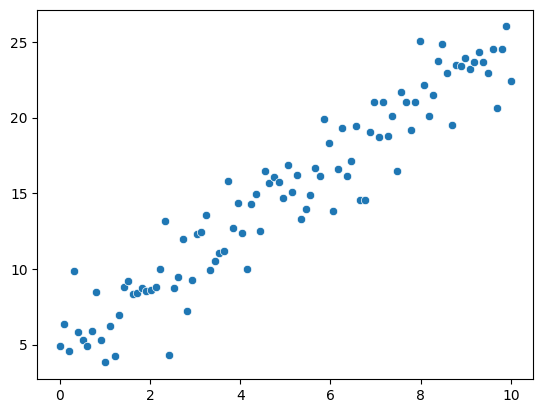

In [ ]:
sns.scatterplot(x=X,y=Y)

In [ ]:
def linear(a, b, x):
    return a*x + b

-8 -7


<Axes: >

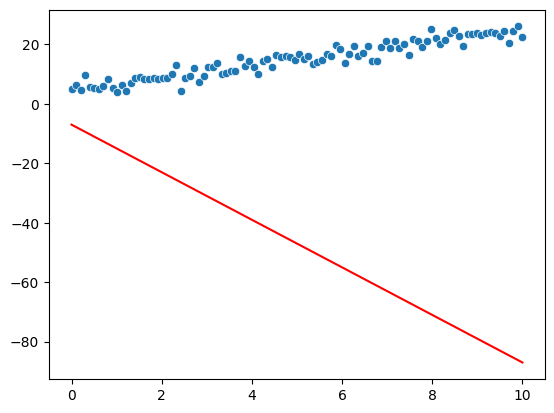

In [ ]:
a = np.random.randint(-10,10)
b = np.random.randint(-10,10)
print(a,b)
sns.scatterplot(x=X,y=Y)
sns.lineplot(x=X,y=linear(a,b,X), color="red")

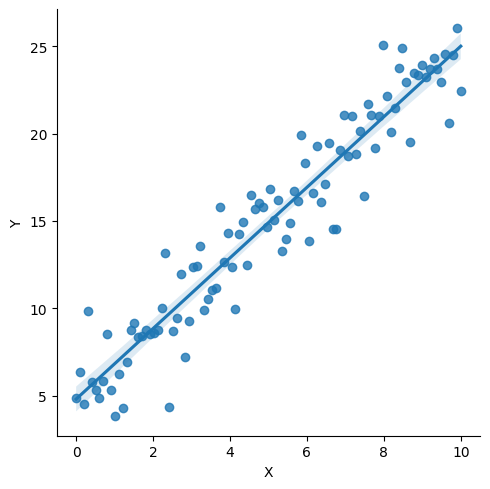

In [ ]:
sns.lmplot(x="X", y="Y", data=pd.DataFrame({"X": X, "Y": Y}))

# The loss landscape

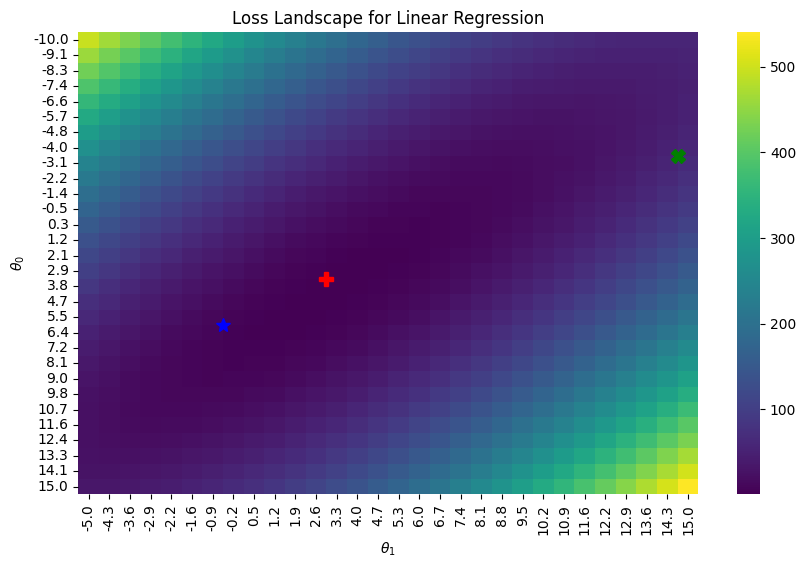

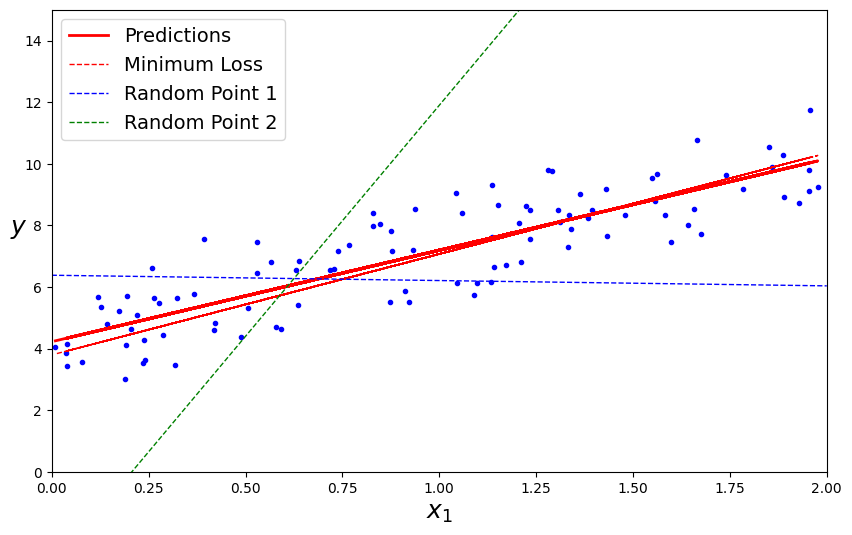

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Generate synthetic data
np.random.seed(0)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# Linear Regression
X_b = np.c_[np.ones((100, 1)), X]  # Add bias term
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

# Loss landscape
theta0_vals = np.linspace(-10, 15, 30)
theta1_vals = np.linspace(-5, 15, 30)
losses = np.zeros((len(theta0_vals), len(theta1_vals)))
for i, theta0 in enumerate(theta0_vals):
    for j, theta1 in enumerate(theta1_vals):
        theta = np.array([[theta0], [theta1]])
        predictions = X_b.dot(theta)
        losses[i, j] = np.mean((y - predictions) ** 2)

# Find minimum
min_loss_index = np.unravel_index(np.argmin(losses), losses.shape)
min_theta0 = theta0_vals[min_loss_index[0]]
min_theta1 = theta1_vals[min_loss_index[1]]


# Plot the loss landscape
plt.figure(figsize=(10, 6))
sns.heatmap(losses, cmap='viridis', xticklabels=np.round(theta1_vals, 1), yticklabels=np.round(theta0_vals, 1))
plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_0$")
plt.title("Loss Landscape for Linear Regression")

# mark minimum
plt.plot(np.where(theta1_vals==min_theta1)[0][0],np.where(theta0_vals==min_theta0)[0][0],'P',markersize=10,color='r')


# two other random points
random_point_1_theta0 = np.random.choice(theta0_vals)
random_point_1_theta1 = np.random.choice(theta1_vals)
random_point_2_theta0 = np.random.choice(theta0_vals)
random_point_2_theta1 = np.random.choice(theta1_vals)

plt.plot(np.where(theta1_vals==random_point_1_theta1)[0][0],np.where(theta0_vals==random_point_1_theta0)[0][0],'*',markersize=10,color='b')
plt.plot(np.where(theta1_vals==random_point_2_theta1)[0][0],np.where(theta0_vals==random_point_2_theta0)[0][0],'X',markersize=10,color='g')

plt.show()

# plot best fit and data
plt.figure(figsize=(10, 6))
plt.plot(X, y, "b.")
plt.plot(X, X_b.dot(theta_best), "r-", linewidth=2, label="Predictions")

# best fit
plt.plot(X, X_b.dot(np.array([[min_theta0],[min_theta1]])), "r--", linewidth=1, label="Minimum Loss")


# Random points
X_new=np.array([[0],[2]])
X_new_b = np.c_[np.ones((2, 1)), X_new]
plt.plot(X_new, X_new_b.dot(np.array([[random_point_1_theta0],[random_point_1_theta1]])), "b--", linewidth=1, label="Random Point 1")
plt.plot(X_new, X_new_b.dot(np.array([[random_point_2_theta0],[random_point_2_theta1]])), "g--", linewidth=1, label="Random Point 2")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.legend(loc="upper left", fontsize=14)
plt.axis([0, 2, 0, 15])
plt.show()


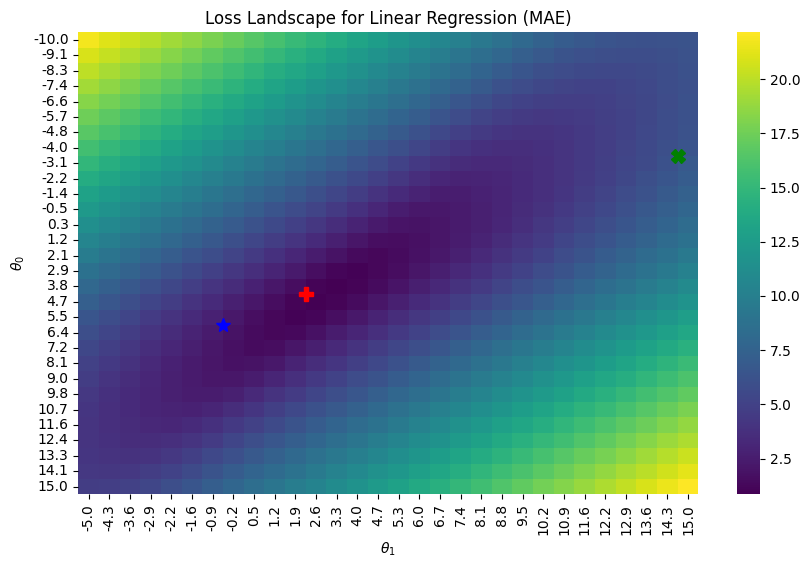

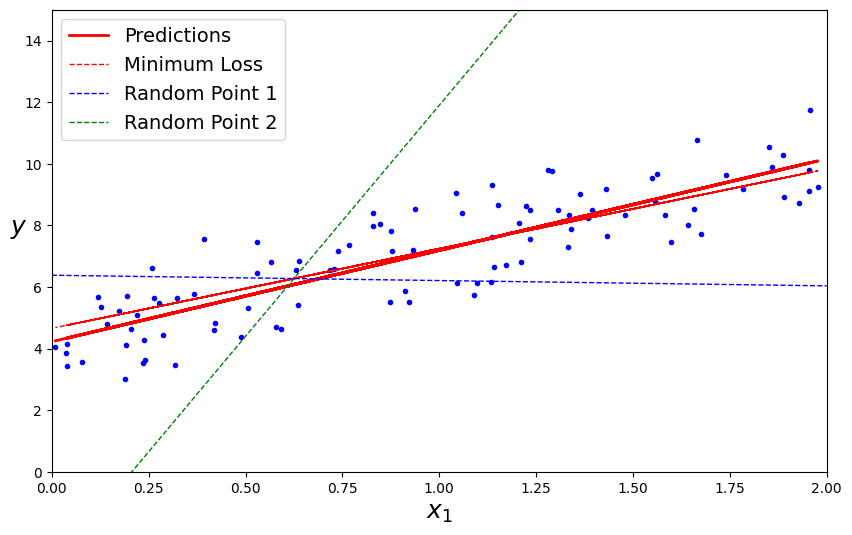

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Generate synthetic data
np.random.seed(0)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# Linear Regression
X_b = np.c_[np.ones((100, 1)), X]  # Add bias term
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

# Loss landscape (MAE)
theta0_vals = np.linspace(-10, 15, 30)
theta1_vals = np.linspace(-5, 15, 30)
losses = np.zeros((len(theta0_vals), len(theta1_vals)))
for i, theta0 in enumerate(theta0_vals):
    for j, theta1 in enumerate(theta1_vals):
        theta = np.array([[theta0], [theta1]])
        predictions = X_b.dot(theta)
        losses[i, j] = np.mean(np.abs(y - predictions)) # Changed to MAE

# Find minimum
min_loss_index = np.unravel_index(np.argmin(losses), losses.shape)
min_theta0 = theta0_vals[min_loss_index[0]]
min_theta1 = theta1_vals[min_loss_index[1]]

# Plot the loss landscape
plt.figure(figsize=(10, 6))
sns.heatmap(losses, cmap='viridis', xticklabels=np.round(theta1_vals, 1), yticklabels=np.round(theta0_vals, 1))
plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_0$")
plt.title("Loss Landscape for Linear Regression (MAE)") # Changed title

# mark minimum
plt.plot(np.where(theta1_vals==min_theta1)[0][0],np.where(theta0_vals==min_theta0)[0][0],'P',markersize=10,color='r')

# two other random points
random_point_1_theta0 = np.random.choice(theta0_vals)
random_point_1_theta1 = np.random.choice(theta1_vals)
random_point_2_theta0 = np.random.choice(theta0_vals)
random_point_2_theta1 = np.random.choice(theta1_vals)

plt.plot(np.where(theta1_vals==random_point_1_theta1)[0][0],np.where(theta0_vals==random_point_1_theta0)[0][0],'*',markersize=10,color='b')
plt.plot(np.where(theta1_vals==random_point_2_theta1)[0][0],np.where(theta0_vals==random_point_2_theta0)[0][0],'X',markersize=10,color='g')

plt.show()

# plot best fit and data
plt.figure(figsize=(10, 6))
plt.plot(X, y, "b.")
plt.plot(X, X_b.dot(theta_best), "r-", linewidth=2, label="Predictions")

# best fit
plt.plot(X, X_b.dot(np.array([[min_theta0],[min_theta1]])), "r--", linewidth=1, label="Minimum Loss")

# Random points
X_new=np.array([[0],[2]])
X_new_b = np.c_[np.ones((2, 1)), X_new]
plt.plot(X_new, X_new_b.dot(np.array([[random_point_1_theta0],[random_point_1_theta1]])), "b--", linewidth=1, label="Random Point 1")
plt.plot(X_new, X_new_b.dot(np.array([[random_point_2_theta0],[random_point_2_theta1]])), "g--", linewidth=1, label="Random Point 2")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.legend(loc="upper left", fontsize=14)
plt.axis([0, 2, 0, 15])
plt.show()


# Gradient descent

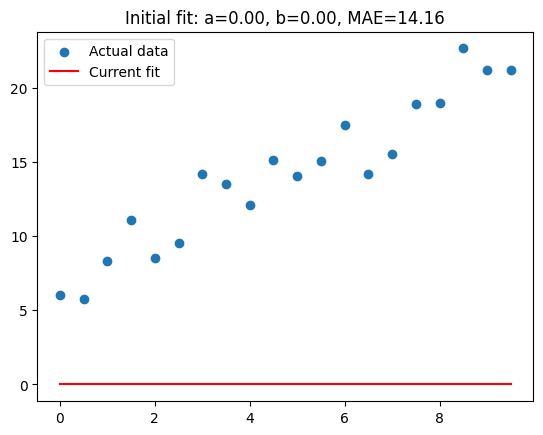

In [ ]:
# Cell 1: Import libraries and initialize variables
import numpy as np
import matplotlib.pyplot as plt

# Generate sample data
np.random.seed(42)
X = np.arange(0, 10, 0.5)
y = 2 * X + 5 + np.random.normal(0, 2, len(X))  # True relationship: y = 2x + 5 + noise

# Initialize parameters
a = 0.0  # slope
b = 0.0  # intercept
learning_rate = 0.1

# Define model and loss function
def model(X, a, b):
    return a * X + b

def mae_loss(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

# Initial predictions and loss
y_pred = model(X, a, b)
initial_loss = mae_loss(y, y_pred)

# Plot initial fit
plt.scatter(X, y, label='Actual data')
plt.plot(X, y_pred, color='red', label='Current fit')
plt.title(f'Initial fit: a={a:.2f}, b={b:.2f}, MAE={initial_loss:.2f}')
plt.legend()
plt.show()

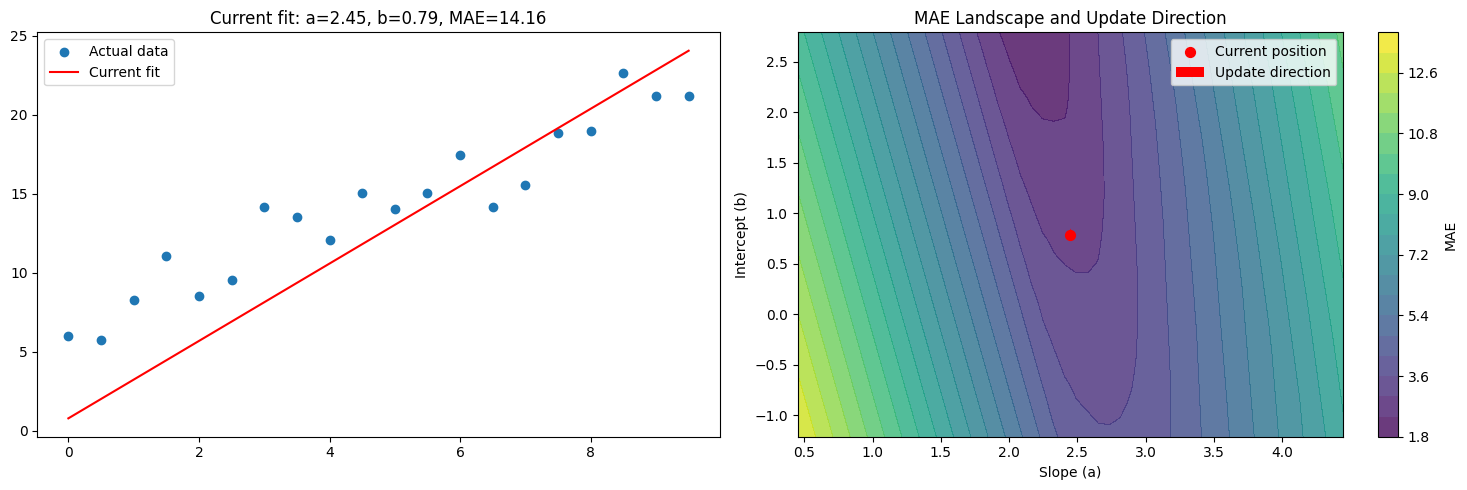

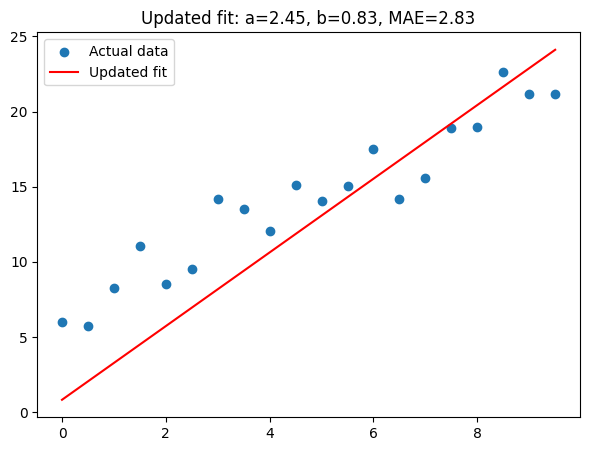

New parameters: a=2.4500, b=0.8300
Previous MAE: 14.1574
New MAE: 2.8321


In [ ]:
# Cell 2: Run one step of gradient descent (updated with MAE landscape)
# Calculate gradients (using subgradients for MAE)
error = y_pred - y
grad_a = np.mean(np.sign(error) * X)
grad_b = np.mean(np.sign(error))

# Create parameter grid around current parameters
grid_size = 2.0  # Area to visualize around current parameters
a_values = np.linspace(a - grid_size, a + grid_size, 50)
b_values = np.linspace(b - grid_size, b + grid_size, 50)
A, B = np.meshgrid(a_values, b_values)

# Vectorized MAE calculation
X_3d = X.reshape(1, 1, -1)
y_3d = y.reshape(1, 1, -1)
predictions = A[..., np.newaxis] * X_3d + B[..., np.newaxis]
mae_values = np.mean(np.abs(predictions - y_3d), axis=2)

# Create figure with subplots
fig = plt.figure(figsize=(15, 5))

# First subplot: Data and current fit
ax1 = plt.subplot(1, 2, 1)
ax1.scatter(X, y, label='Actual data')
ax1.plot(X, y_pred, color='red', label='Current fit')
ax1.set_title(f'Current fit: a={a:.2f}, b={b:.2f}, MAE={initial_loss:.2f}')
ax1.legend()

# Second subplot: MAE landscape and update direction
ax2 = plt.subplot(1, 2, 2)
contour = ax2.contourf(A, B, mae_values, levels=20, alpha=0.8)
plt.colorbar(contour, ax=ax2, label='MAE')
ax2.scatter(a, b, c='red', s=50, label='Current position')

# Draw gradient direction arrow (scaled for visibility)
step_scale = 1.5  # Makes the arrow more visible
ax2.quiver(a, b,
           -grad_a * learning_rate * step_scale,
           -grad_b * learning_rate * step_scale,
           color='red', scale=1, scale_units='xy',
           angles='xy', width=0.005,
           label='Update direction')

ax2.set_title('MAE Landscape and Update Direction')
ax2.set_xlabel('Slope (a)')
ax2.set_ylabel('Intercept (b)')
ax2.legend()

plt.tight_layout()
plt.show()

# Update parameters
a -= learning_rate * grad_a
b -= learning_rate * grad_b

# Make new predictions and calculate loss
y_pred = model(X, a, b)
current_loss = mae_loss(y, y_pred)

# Show updated fit
plt.figure(figsize=(7, 5))
plt.scatter(X, y, label='Actual data')
plt.plot(X, y_pred, color='red', label='Updated fit')
plt.title(f'Updated fit: a={a:.2f}, b={b:.2f}, MAE={current_loss:.2f}')
plt.legend()
plt.show()

print(f"New parameters: a={a:.4f}, b={b:.4f}")
print(f"Previous MAE: {initial_loss:.4f}")
print(f"New MAE: {current_loss:.4f}")

# Gradient Descent Mathematics for MAE Loss

## Model and Loss Function

**Linear Regression Model**:
$$ \hat{y}_i = a \cdot x_i + b $$

**Mean Absolute Error (MAE)**:
$$ \mathcal{L} = \frac{1}{N} \sum_{i=1}^{N} |\hat{y}_i - y_i| $$

## Gradient Derivation

### Parameters to Update:
$$ \theta = \begin{bmatrix} a \\ b \end{bmatrix} $$

### Subgradients (since MAE is non-differentiable at 0)
For each data point $(x_i, y_i)$:

**Error Term**:
$$ e_i = \hat{y}_i - y_i = (a \cdot x_i + b) - y_i $$

**Subgradient for $a$**:
$$ \frac{\partial \mathcal{L}}{\partial a} = \frac{1}{N} \sum_{i=1}^{N} \text{sign}(e_i) \cdot x_i $$

**Subgradient for $b$**:
$$ \frac{\partial \mathcal{L}}{\partial b} = \frac{1}{N} \sum_{i=1}^{N} \text{sign}(e_i) $$

Where:
$$ \text{sign}(e_i) = \begin{cases}
1 & \text{if } e_i > 0 \\
0 & \text{if } e_i = 0 \\
-1 & \text{if } e_i < 0
\end{cases} $$

## Parameter Update Rule

**Gradient Descent Update**:
$$ \theta_{\text{new}} = \theta_{\text{old}} - \eta \cdot \nabla\mathcal{L} $$

**Component-wise Updates**:
$$ a_{\text{new}} = a_{\text{old}} - \eta \cdot \frac{\partial \mathcal{L}}{\partial a} $$
$$ b_{\text{new}} = b_{\text{old}} - \eta \cdot \frac{\partial \mathcal{L}}{\partial b} $$

Where:
- $\eta$ is the learning rate
- $\nabla\mathcal{L}$ is the gradient vector $\begin{bmatrix} \frac{\partial \mathcal{L}}{\partial a} \\ \frac{\partial \mathcal{L}}{\partial b} \end{bmatrix}$

## Implementation Correspondence

The code calculates these gradients as:
